
# **Proyecto 2**
### **Minería de Grafos**  

     Docente: Victor Hugo Ortega
     Aissa Berenice González Fosado
     Maximiliano Aguayo
     Ivan Morales

<img src="https://iteso.mx/documents/27014/202031/Logo-ITESO-MinimoH.png"
     width="400"/>

---

Este proyecto aplica la metodología KDG (Knowledge Discovery in Graphs) a la red del Metro de la Ciudad de México. Se construye un grafo en el que las estaciones se modelan como nodos y las conexiones entre estaciones consecutivas como aristas, y sobre esta estructura se realizan análisis exploratorio, de centralidad, de comunidades y de búsqueda de caminos, con el fin de caracterizar la topología y conectividad del sistema.

<img src="https://realestatemarket.com.mx/images/articles/141-ciudad-de-mexico/01-full/172-nueva-linea-1-del-stc-metro-capitalino.jpg"
     align="right"
     width="500"/>

Los datos utilizados se extrajeron del Portal de Datos Abiertos de la Ciudad de México, específicamente del conjunto "Ubicación de líneas y estaciones del Sistema de Transporte Colectivo Metro", publicado por la Secretaría de Movilidad (SEMOVI), disponible en https://datos.cdmx.gob.mx/dataset/lineas-y-estaciones-del-metro/resource/b9b61c06-8325-4df1-85c6-10c3aa7af1ac.

El recurso contiene la geolocalización de las 12 líneas y las estaciones del STC Metro en formato shapefile. A partir de esta fuente, las estaciones se descargaron y se modelaron como nodos del grafo, mientras que las líneas se emplearon para definir las relaciones entre estaciones consecutivas. Mediante un proceso de conversión geoespacial se extrajeron las propiedades y coordenadas de cada elemento, conformando así la estructura del grafo de la red sobre la que se llevarán a cabo los análisis posteriores.

## **Pipeline de construcción del grafo**
Construcción de un grafo de la red del STC Metro a partir de los datos oficiales SHP:
  - Nodos: estaciones
  - Aristas: conexiones entre estaciones consecutivas de la misma línea, ponderadas por la distancia real de vía (en metros)

In [5]:
#Librerías
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.ops import linemerge

In [6]:
# 1. Carga de datos
RAW = Path('data/raw')
OUT = Path('data/processed')
OUT.mkdir(parents=True, exist_ok=True)

gdf_lineas     = gpd.read_file(RAW / 'STC_Metro_lineas_utm14n.shp')
gdf_estaciones = gpd.read_file(RAW / 'STC_Metro_estaciones_utm14n.shp')

In [7]:
# 2. Alineación de los sistemas de referencia (CRS)
#    Las líneas vienen en EPSG:32614 (UTM 14N, metros) usamos esa proyección para los cálculos de distancia.
#    Las estaciones vienen en EPSG:4326 (lat/lon) las reproyectamos para que coincidan, y conservamos una copia en lat/lon para el CSV.
gdf_lineas_m      = gdf_lineas
gdf_estaciones_m  = gdf_estaciones.to_crs('EPSG:32614')
gdf_estaciones_ll = gdf_estaciones.to_crs('EPSG:4326')

In [8]:
# 3. Inspección de los datos
print("Líneas:", gdf_lineas_m.shape,
      "| geom:", gdf_lineas_m.geometry.geom_type.value_counts().to_dict())
print("Estaciones:", gdf_estaciones_m.shape,
      "| geom:", gdf_estaciones_m.geometry.geom_type.value_counts().to_dict())
print("Líneas en gdf_lineas:    ", sorted(gdf_lineas_m['LINEA'].unique()))
print("Líneas en gdf_estaciones:", sorted(gdf_estaciones_m['LINEA'].unique()))



Líneas: (12, 4) | geom: {'LineString': 12}
Estaciones: (195, 10) | geom: {'Point': 195}
Líneas en gdf_lineas:     ['1', '12', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B']
Líneas en gdf_estaciones: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '12', 'A', 'B']


In [9]:
# 4. Construcción de la lista de aristas con distancia real de vía
#    Para cada línea:
#      a) se unen todas las geometrías en un solo LineString
#      b) cada estación se "proyecta" sobre la línea (snap)
#      c) la distancia entre dos estaciones consecutivas =
#         diferencia de su "distancia recorrida a lo largo de la línea"

edges = []

for linea_id, line_rows in gdf_lineas_m.groupby('LINEA'):
    # Unimos todos los segmentos de la línea en una sola geometría
    line_geom = line_rows.geometry.union_all()
    if line_geom.geom_type == 'MultiLineString':
        line_geom = linemerge(line_geom)

    # Estaciones de esta línea, ordenadas por EST (orden a lo largo de la línea)
    stations = (gdf_estaciones_m[gdf_estaciones_m['LINEA'] == linea_id]
                .sort_values('EST')
                .reset_index(drop=True))
    if len(stations) < 2:
        continue

    # Cada estación se proyecta sobre la línea, distancia acumulada en metros
    stations = stations.copy()
    stations['along_m'] = stations.geometry.apply(line_geom.project)

    # Pares consecutivos = aristas del grafo
    for i in range(len(stations) - 1):
        a, b = stations.iloc[i], stations.iloc[i + 1]
        dist_track_m    = abs(b['along_m'] - a['along_m'])     # distancia real de vía
        dist_straight_m = a.geometry.distance(b.geometry)      # distancia en línea recta

        # Coordenadas geográficas (lon/lat) para guardar en el CSV
        a_ll = gdf_estaciones_ll.loc[a.name, 'geometry'] if a.name in gdf_estaciones_ll.index else None
        b_ll = gdf_estaciones_ll.loc[b.name, 'geometry'] if b.name in gdf_estaciones_ll.index else None

        edges.append({
            'origen':             a['NOMBRE'],
            'destino':            b['NOMBRE'],
            'linea':              linea_id,
            'sistema':            a['SISTEMA'],
            'tipo_origen':        a['TIPO'],
            'tipo_destino':       b['TIPO'],
            'alcaldia_origen':    a['ALCALDIAS'],
            'alcaldia_destino':   b['ALCALDIAS'],
            'origen_lon':         a_ll.x if a_ll is not None else None,
            'origen_lat':         a_ll.y if a_ll is not None else None,
            'destino_lon':        b_ll.x if b_ll is not None else None,
            'destino_lat':        b_ll.y if b_ll is not None else None,
            'distancia_track_m':  dist_track_m,
            'distancia_track_km': dist_track_m / 1000,
            'distancia_recta_m':  dist_straight_m,
            'distancia_recta_km': dist_straight_m / 1000,
        })

df_edges = pd.DataFrame(edges)

In [10]:
# 5. Validación
total_track    = df_edges['distancia_track_km'].sum()
total_straight = df_edges['distancia_recta_km'].sum()

print(f"\nAristas generadas: {len(df_edges)}")
print(f"Longitud total por vía:    {total_track:.2f} km   (referencia oficial: ~226 km)")
print(f"Longitud total en línea recta: {total_straight:.2f} km")
print(f"La vía es {(total_track/total_straight - 1)*100:.1f}% más larga que la línea recta\n")
print(df_edges.head())


Aristas generadas: 48
Longitud total por vía:    59.16 km   (referencia oficial: ~226 km)
Longitud total en línea recta: 57.02 km
La vía es 3.7% más larga que la línea recta

       origen     destino linea    sistema tipo_origen tipo_destino  \
0     Tláhuac   Tlaltenco    12  STC Metro    Terminal   Intermedia   
1   Tlaltenco  Zapotitlán    12  STC Metro  Intermedia   Intermedia   
2  Zapotitlán    Nopalera    12  STC Metro  Intermedia   Intermedia   
3    Nopalera      Olivos    12  STC Metro  Intermedia   Intermedia   
4      Olivos     Tezonco    12  STC Metro  Intermedia   Intermedia   

  alcaldia_origen alcaldia_destino  origen_lon  origen_lat  destino_lon  \
0         Tláhuac          Tláhuac  -99.074736   19.416334   -99.082289   
1         Tláhuac          Tláhuac  -99.082289   19.411920   -99.090210   
2         Tláhuac          Tláhuac  -99.090210   19.416478   -99.096259   
3         Tláhuac          Tláhuac  -99.096259   19.419942   -99.102774   
4         Tláhuac     

In [11]:
# 6. Tabla de nodos (una fila por estación única)
df_nodes = (gdf_estaciones_ll
            .drop_duplicates(subset='NOMBRE')
            [['NOMBRE', 'LINEA', 'SISTEMA', 'TIPO', 'ALCALDIAS',
              'AÑO', 'CVE_EST', 'geometry']]
            .copy())
df_nodes['lon'] = df_nodes.geometry.x
df_nodes['lat'] = df_nodes.geometry.y
df_nodes = df_nodes.drop(columns='geometry')


In [12]:
# 7. Guardado de  los nodos y las relaciones
edges_path = OUT / 'metro_edges.csv'
nodes_path = OUT / 'metro_nodes.csv'

df_edges.to_csv(edges_path, index=False)
df_nodes.to_csv(nodes_path, index=False, encoding='utf-8-sig')

print(f"\nGuardado {edges_path}  ({len(df_edges)} aristas)")
print(f"Guardado {nodes_path}  ({len(df_nodes)} nodos)")


Guardado data\processed\metro_edges.csv  (48 aristas)
Guardado data\processed\metro_nodes.csv  (163 nodos)


## **EDA**
Estadísticas básicas y visualizaciones para entender la estructura de la red antes de construir el grafo formal.

In [30]:
print("Resumen general")
print(f"Total de estaciones únicas: {df_nodes['NOMBRE'].nunique()}")
print(f"Total de registros estación-línea: {len(gdf_estaciones)}")
print(f"Total de líneas: {df_nodes['LINEA'].nunique()}")
print(f"Total de aristas (conexiones): {len(df_edges)}")

Resumen general
Total de estaciones únicas: 163
Total de registros estación-línea: 195
Total de líneas: 12
Total de aristas (conexiones): 48


In [29]:
print("Estaciones por línea")
estaciones_por_linea = (gdf_estaciones.groupby('LINEA')['NOMBRE']
                        .count().sort_values(ascending=False))
print(estaciones_por_linea)

Estaciones por línea
LINEA
02    24
03    21
B     21
01    20
12    20
08    19
07    14
05    13
09    12
06    11
04    10
A     10
Name: NOMBRE, dtype: int64


In [28]:
transbordos = (gdf_estaciones.groupby('NOMBRE')['LINEA']
               .nunique().sort_values(ascending=False))
transbordos = transbordos[transbordos > 1]
print(f"Estaciones de transbordo: {len(transbordos)}")
print(transbordos)

Estaciones de transbordo: 28
NOMBRE
Pantitlán                 4
Chabacano                 3
Tacubaya                  3
Santa Anita               2
Jamaica                   2
Instituto del Petróleo    2
Consulado                 2
Tacuba                    2
Pino Suárez               2
San Lázaro                2
Candelaria                2
Deportivo 18 de Marzo     2
Hidalgo                   2
Guerrero                  2
Salto del Agua            2
El Rosario                2
Ermita                    2
Garibaldi/Lagunilla       2
Centro Médico             2
Mixcoac                   2
Morelos                   2
La Raza                   2
Oceanía                   2
Martín Carrera            2
Balderas                  2
Zapata                    2
Atlalilco                 2
Bellas Artes              2
Name: LINEA, dtype: int64


In [27]:
print("Distancia entre estaciones consecutivas (km)")
print(df_edges['distancia_track_km'].describe().round(3))

Distancia entre estaciones consecutivas (km)
count    48.000
mean      1.232
std       0.444
min       0.570
25%       0.874
50%       1.246
75%       1.515
max       2.356
Name: distancia_track_km, dtype: float64


In [26]:
print("Top 10 alcaldías con más estaciones")
print(df_nodes['ALCALDIAS'].value_counts().head(10))

Top 10 alcaldías con más estaciones
ALCALDIAS
Cuauhtémoc             30
Venustiano Carranza    20
Iztapalapa             19
Benito Juárez          17
Gustavo A. Madero      16
Miguel Hidalgo         12
Azcapotzalco            9
Tláhuac                 5
Iztacalco               5
Coyoacán                5
Name: count, dtype: int64


In [25]:
print("Tipos de estación")
print(df_nodes['TIPO'].value_counts())

Tipos de estación
TIPO
Intermedia               123
Transbordo                23
Terminal                  12
Terminal / Transbordo      5
Name: count, dtype: int64


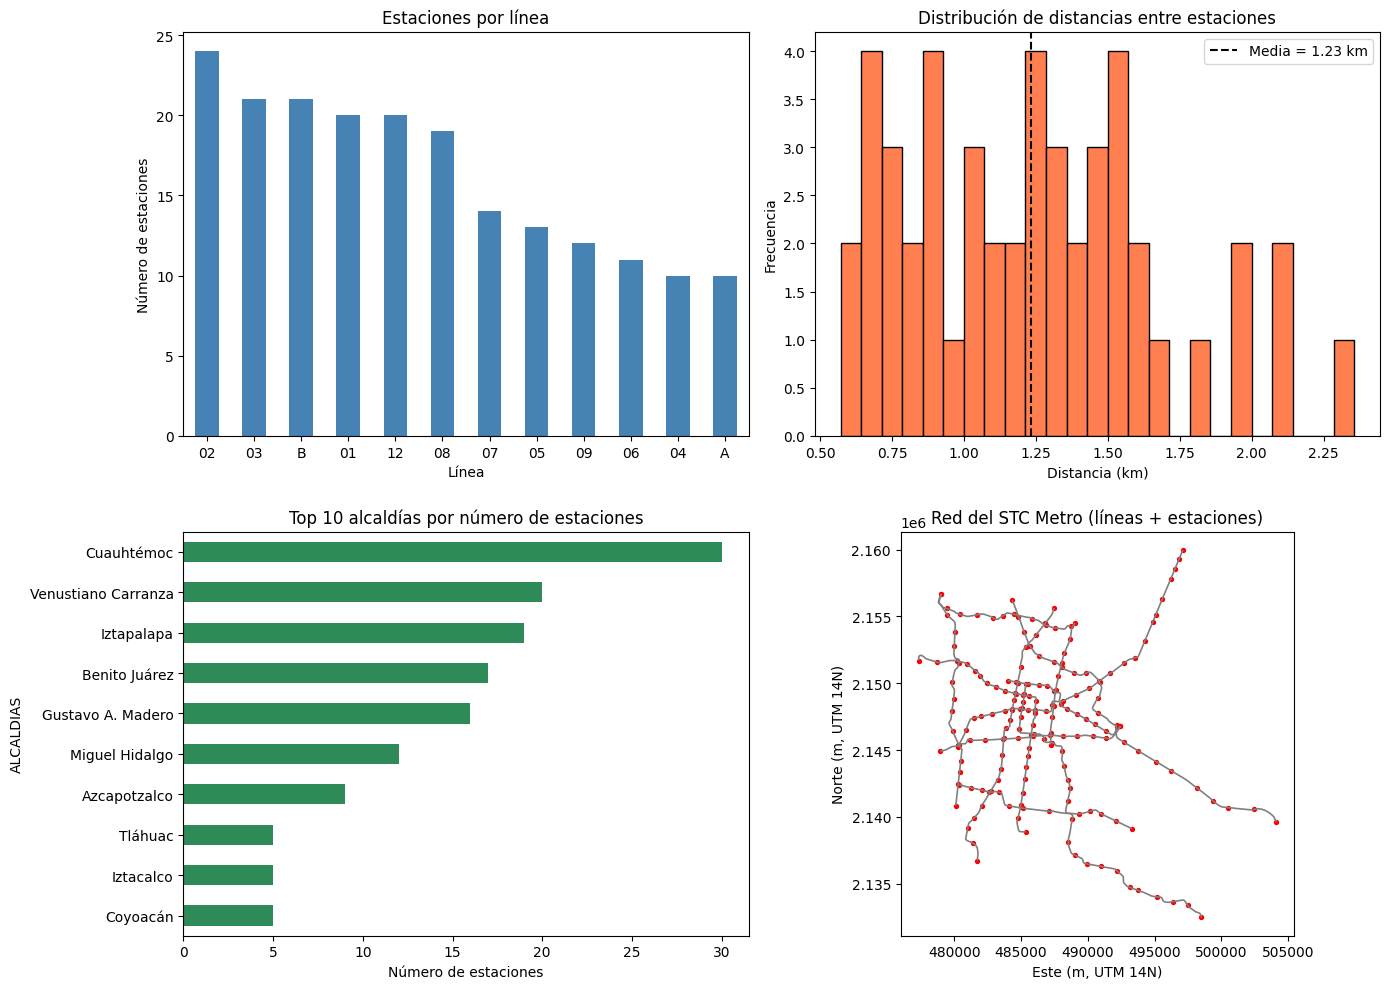


Gráfica guardada en data\processed\eda_resumen.png


In [24]:
# Visualizaciones

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Estaciones por línea
estaciones_por_linea.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Estaciones por línea')
axes[0, 0].set_xlabel('Línea')
axes[0, 0].set_ylabel('Número de estaciones')
axes[0, 0].tick_params(axis='x', rotation=0)

# Histograma de distancias
axes[0, 1].hist(df_edges['distancia_track_km'], bins=25,
                color='coral', edgecolor='black')
axes[0, 1].axvline(df_edges['distancia_track_km'].mean(),
                   color='black', linestyle='--',
                   label=f"Media = {df_edges['distancia_track_km'].mean():.2f} km")
axes[0, 1].set_title('Distribución de distancias entre estaciones')
axes[0, 1].set_xlabel('Distancia (km)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()

# Estaciones por alcaldía (top 10)
df_nodes['ALCALDIAS'].value_counts().head(10).plot(
    kind='barh', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Top 10 alcaldías por número de estaciones')
axes[1, 0].set_xlabel('Número de estaciones')
axes[1, 0].invert_yaxis()

# Mapa: líneas + estaciones
gdf_lineas_m.plot(ax=axes[1, 1], color='gray', linewidth=1.2)
gdf_estaciones_m.plot(ax=axes[1, 1], color='red', markersize=8)
axes[1, 1].set_title('Red del STC Metro (líneas + estaciones)')
axes[1, 1].set_xlabel('Este (m, UTM 14N)')
axes[1, 1].set_ylabel('Norte (m, UTM 14N)')

plt.tight_layout()
plt.savefig(OUT / 'eda_resumen.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nGráfica guardada en {OUT/'eda_resumen.png'}")